# Polar plot
Based on https://github.com/climberlenny/test_openberg/blob/main/toolbox/postprocessing.py

In [1]:
cd ~/work/tutorials/sources/OpenDrift/openberg_july2026

/home/jovyan/work/tutorials/sources/OpenDrift/openberg_july2026


In [2]:
from src.utils import *
from openberg_july2026.src2.utils2 import *
from openberg_july2026.src2.utils3 import *
import glob

In [3]:
# Read and subset tracker data
ib = 'iceberg2018b'
#read obs
with xr.open_dataset('./input/merged_obs10.nc') as ds:
    obs = ds.sel(iceberg=ib,trajectory_id=ib) 
    obs_seed = obs.isel(time=(obs.seed_idx==1))

In [4]:
#read sim
file_contain_all = [ib,]
file_contain_any = ['_']
file_notcontain = ['test','idx','main','next']#'test','wa','next','glorys']#['topaz4','glorys','slope','era5','almost','stokes',]
file_l = glob.glob("./results/*.nc")#['./results/juliette_topaz6_topaz4_windglophynrt.nc',]
file_l = [f for f in file_l if all(ff in f for ff in file_contain_all)] #filtering for required keywords
file_l = [f for f in file_l if any(ff in f for ff in file_contain_any)] #filtering for required keywords
file_l = [f for f in file_l if all(ff not in f for ff in file_notcontain)] #filtering for neglected keywords
file_l = file_l#[::-1]
print(file_l)

['./results/iceberg2018b_gebco_topaz4_windglophyre.nc', './results/iceberg2018b_gebco_glorys_windglophyre_joined.nc', './results/iceberg2018b_gebco_topaz6_topaz4_windglophyre_joined.nc']


In [5]:
#dicts and definitions
from openberg_july2026.src2.utils3 import legenddict_full 
legenddict = dict.fromkeys([f.split('/')[-1][:-3] for f in file_l])
for f in legenddict:
    ll = []
    for l in legenddict_full:
        if l.lower() in f: ll = ll+[l]
    legenddict[f]={'col':legenddict_full[ll[-1]]['col'], 'alpha':1, 'kw':', '.join(ll),'zo':legenddict_full[ll[-1]]['zo'],
                 'traj':np.arange(obs.time.size*11)}
#manual adaptions
legenddict['iceberg2018b_gebco_topaz4_windglophyre']['zo']=25

legenddict 

{'iceberg2018b_gebco_topaz4_windglophyre': {'col': 'darkslateblue',
  'alpha': 1,
  'kw': 'WINDGLOPHYRE, ICEBERG, TOPAZ4',
  'zo': 25,
  'traj': array([    0,     1,     2, ..., 54942, 54943, 54944], shape=(54945,))},
 'iceberg2018b_gebco_glorys_windglophyre_joined': {'col': 'darkolivegreen',
  'alpha': 1,
  'kw': 'WINDGLOPHYRE, ICEBERG, GLORYS',
  'zo': 20,
  'traj': array([    0,     1,     2, ..., 54942, 54943, 54944], shape=(54945,))},
 'iceberg2018b_gebco_topaz6_topaz4_windglophyre_joined': {'col': 'turquoise',
  'alpha': 1,
  'kw': 'WINDGLOPHYRE, ICEBERG, TOPAZ4, TOPAZ6',
  'zo': 24,
  'traj': array([    0,     1,     2, ..., 54942, 54943, 54944], shape=(54945,))}}

In [6]:
simall = xr.open_mfdataset(file_l,concat_dim="run",combine="nested")
simall = simall.assign_coords(run=list(legenddict.keys()))

/tmp/ipykernel_14292/3927061789.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  simall = xr.open_mfdataset(file_l,concat_dim="run",combine="nested")


In [7]:
# --- Subset---
apn = 1

# ---Trajectory subset
sim = simall
if ib in dict_traj.keys():
    for run in list(sim.run.values):
        if run in dict_traj[ib]: 
            sim = sim.sel(trajectory=dict_traj[ib][run])
            print('Trajectory subset applied on ',run)

# ---Time subset
if apn!=None: 
    sim = sim.sel(time=dict_analysis_period[ib][apn])
    print('Time subset applied: ',apn)

# ---time frequnecy subset
days = obs.time.dt.floor("D")
days2 = np.arange(obs_seed.time.dt.floor("D")[0].values,
                  obs_seed.time.dt.floor("D")[-1].values+np.timedelta64(str(obs.seed_freq.values)[:-1],str(obs.seed_freq.values)[-1]),
                  dtype='datetime64[D]')
idx = [
    np.where(days == np.datetime64(d))[0][0]
    for d in days2
    if (days == np.datetime64(d)).any()
]
obs_subtime = obs.isel(time=idx)
sim_obssubtime = sim.sel(time=obs_subtime.time, method="nearest") 

sim_sub = sim_obssubtime
obs_sub = obs_subtime

Time subset applied:  1


iceberg2018b_gebco_topaz4_windglophyre 0 120 0 120 darkslateblue
iceberg2018b_gebco_glorys_windglophyre_joined 0 120 0 120 darkolivegreen
iceberg2018b_gebco_topaz6_topaz4_windglophyre_joined 0 120 0 120 turquoise


/opt/conda/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/conda/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/jovyan/work/tutorials/sources/OpenDrift/openberg_july2026/src2/utils3.py:230: RuntimeWarning: All-NaN slice encountered
  for vals in (np.nanmax(R) - np.nanmin(R),
/opt/conda/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


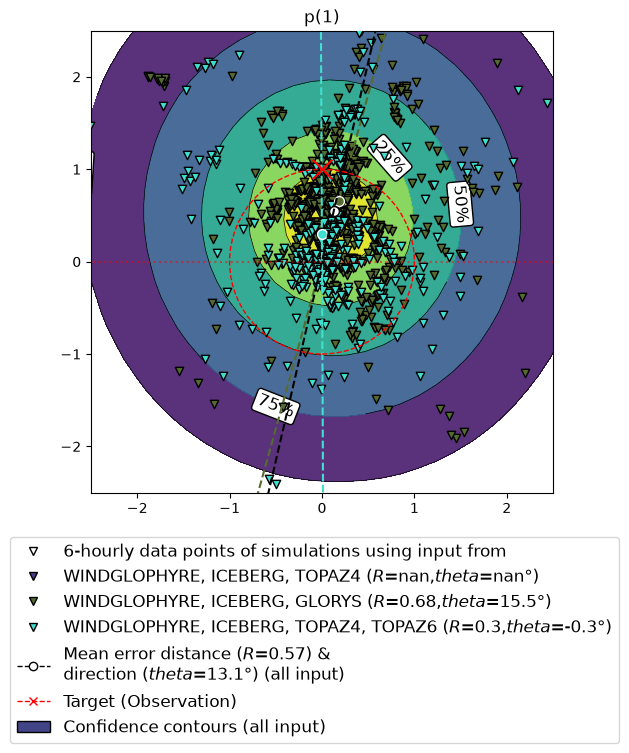

In [8]:
# del polarplot_m
# from openberg_july2026.src2.utils3 import polarplot_m
out = polarplot_m(sim_sub,obs_sub,legenddict,title='p(%s)'%apn)

In [10]:
#means
[{k:(float(v[0]),int(np.round(v[1])))} for k,v in out['mean'].items() if k != 'all']

AttributeError: module 'numpy' has no attribute 'nanround'

In [ ]:
#spreads
[{k:(float(v[1]),int(np.round(v[-1])))} for k,v in out['spread'].items() if k != 'all']

In [11]:
out

{'mean': {'all': [np.float64(0.57), np.float64(13.06)],
  'iceberg2018b_gebco_topaz4_windglophyre': [np.float64(nan), np.float64(nan)],
  'iceberg2018b_gebco_glorys_windglophyre_joined': [np.float64(0.68),
   np.float64(15.47)],
  'iceberg2018b_gebco_topaz6_topaz4_windglophyre_joined': [np.float64(0.3),
   np.float64(-0.26)]},
 'spread': {'all': [np.float64(9.95),
   np.float64(1.77),
   np.float64(358.48),
   np.float64(104.28)],
  'iceberg2018b_gebco_topaz4_windglophyre': [np.float64(nan),
   np.float64(nan),
   np.float64(201.83),
   np.float64(44.45)],
  'iceberg2018b_gebco_glorys_windglophyre_joined': [np.float64(8.38),
   np.float64(1.68),
   np.float64(357.38),
   np.float64(139.87)],
  'iceberg2018b_gebco_topaz6_topaz4_windglophyre_joined': [np.float64(9.95),
   np.float64(1.82),
   np.float64(358.48),
   np.float64(124.46)]}}